# Análisis de Sismicidad en Colombia (2020-2026)
## Análisis exploratorio de datos sísmicos usando el catálogo USGS

**Autor:** John Jairo Mora Soto  
**Fecha:** Mayo 2026  
**Fuente de datos:** USGS Earthquake Catalog  
**Descripción:** Análisis exploratorio de 623 eventos sísmicos registrados 
en Colombia entre 2020 y 2026, incluyendo distribución espacial, 
temporal, análisis de magnitud y profundidad, e identificación 
de zonas sismogénicas.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx
import folium
from folium.plugins import HeatMap

In [5]:
# Carga y preparación de datos
# Fuente: USGS Earthquake Catalog
# https://earthquake.usgs.gov/earthquakes/search/

df = pd.read_csv('query.csv')
df['time'] = pd.to_datetime(df['time'])

# Filtrar Colombia
col = df[df['place'].str.contains('Colombia', na=False)].copy()
col['year'] = col['time'].dt.year
col['month'] = col['time'].dt.month
col['zona'] = col['longitude'].apply(
    lambda x: 'Costa Pacífica' if x < -76.5 else 'Interior continental'
)

print(f"Total sismos región: {len(df)}")
print(f"Total sismos Colombia: {len(col)}")
print(f"Período: {col['time'].dt.year.min()} - {col['time'].dt.year.max()}")
print(f"Columnas: {col.columns.tolist()}")

Total sismos región: 992
Total sismos Colombia: 623
Período: 2020 - 2026
Columnas: ['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst', 'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type', 'horizontalError', 'depthError', 'magError', 'magNst', 'status', 'locationSource', 'magSource', 'year', 'month', 'zona']


In [6]:
# ============================================
# HALLAZGO 1: Colombia concentra el 61% de 
# la sismicidad regional (623 de 992 eventos)
# ============================================

print("Sismos por país:")
print(df['place'].str.extract(r',\s*(.+)$')[0].value_counts())

print("\nEstadísticas de magnitud:")
print(col['mag'].describe().round(2))

print("\nEstadísticas de profundidad:")
print(col['depth'].describe().round(2))

print("\nProfundidad por zona:")
print(col.groupby('zona')['depth'].agg(['mean','median','min','max']).round(1))

Sismos por país:
Colombia                              604
Ecuador                               202
Venezuela                              67
Peru                                   58
Panama                                 31
Bonaire, Saint Eustatius and Saba       1
Name: 0, dtype: int64

Estadísticas de magnitud:
count    623.00
mean       4.45
std        0.31
min        3.60
25%        4.30
50%        4.40
75%        4.60
max        6.30
Name: mag, dtype: float64

Estadísticas de profundidad:
count    623.00
mean     100.73
std       63.29
min        5.06
25%       28.76
50%      142.64
75%      154.42
max      190.29
Name: depth, dtype: float64

Profundidad por zona:
                       mean  median  min    max
zona                                           
Costa Pacífica         29.1    15.1  9.7  136.4
Interior continental  116.8   147.9  5.1  190.3


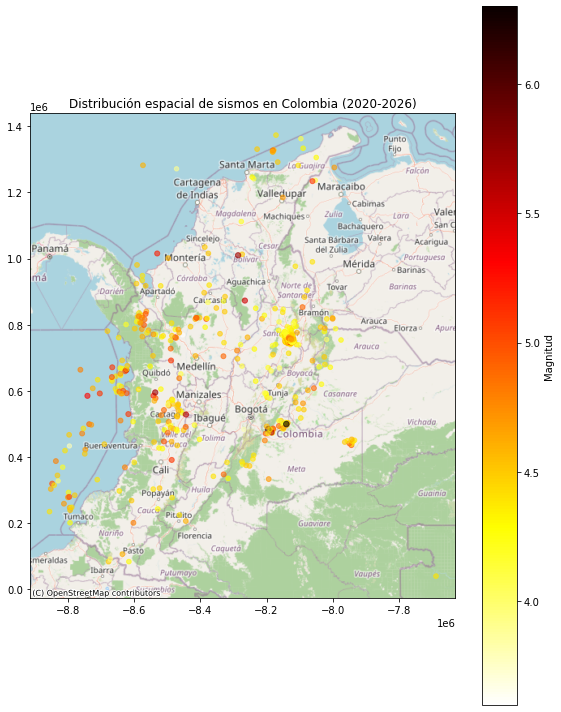

In [7]:
# ============================================
# HALLAZGO 2: Distribución espacial
# Sismos someros en Costa Pacífica (subducción)
# Sismos profundos en interior andino (Wadati-Benioff)
# ============================================

gdf = gpd.GeoDataFrame(
    col,
    geometry=gpd.points_from_xy(col['longitude'], col['latitude']),
    crs='EPSG:4326'
).to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(8, 10))
gdf.plot(
    ax=ax,
    column='mag',
    cmap='hot_r',
    markersize=gdf['mag']*5,
    alpha=0.6,
    legend=True,
    legend_kwds={'label': 'Magnitud'}
)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_title('Distribución espacial de sismos en Colombia (2020-2026)')
plt.tight_layout()
plt.savefig('mapa_sismos.png', dpi=150)
plt.show()

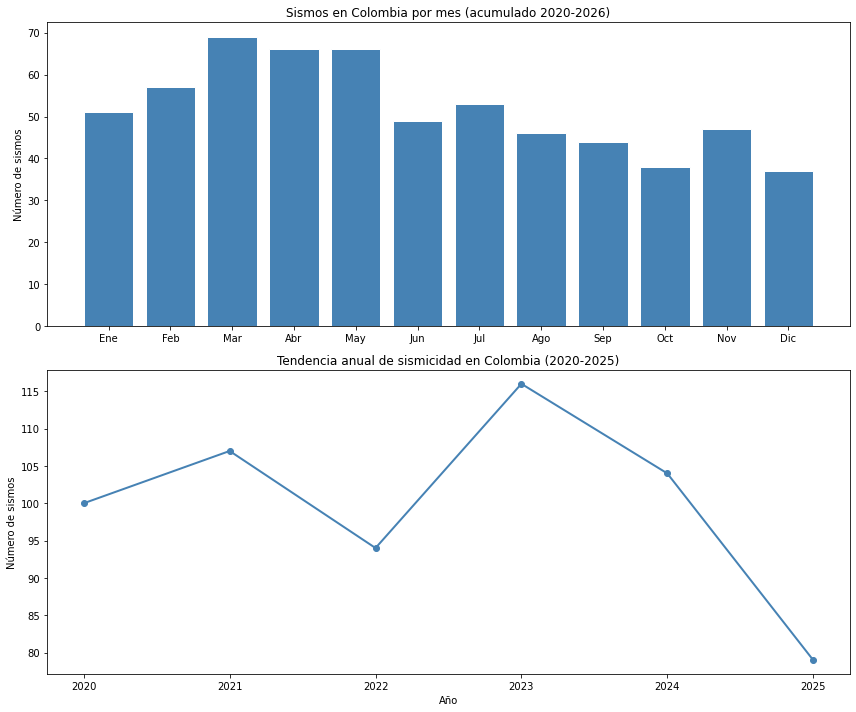

In [8]:
# ============================================
# HALLAZGO 3: Análisis temporal
# No se observa estacionalidad mensual clara
# La sismicidad anual no muestra tendencia
# creciente ni decreciente en 2020-2025
# ============================================

meses = ['Ene','Feb','Mar','Abr','May','Jun',
         'Jul','Ago','Sep','Oct','Nov','Dic']

sismos_mes = col.groupby('month').size()
sismos_año = col[col['year'] < 2026].groupby('year').size()

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Por mes
axes[0].bar(range(1,13), sismos_mes, color='steelblue', edgecolor='white')
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(meses)
axes[0].set_title('Sismos en Colombia por mes (acumulado 2020-2026)')
axes[0].set_ylabel('Número de sismos')

# Por año
axes[1].plot(sismos_año.index, sismos_año.values,
             marker='o', color='steelblue', linewidth=2)
axes[1].set_title('Tendencia anual de sismicidad en Colombia (2020-2025)')
axes[1].set_ylabel('Número de sismos')
axes[1].set_xlabel('Año')

plt.tight_layout()
plt.savefig('analisis_temporal.png', dpi=150)
plt.show()

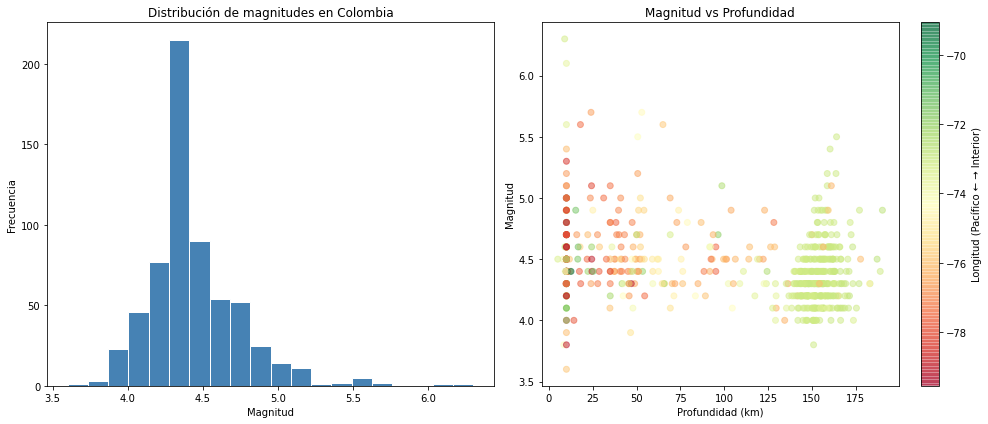

Magnitud media: 4.45 Mw
Sismo máximo: 6.3 Mw en 15 km NE of Paratebueno, Colombia


In [9]:
# ============================================
# HALLAZGO 4: Relación magnitud-profundidad
# Sismos fuertes y someros en lon ~78° 
# → Interfaz de subducción Nazca-Suramérica
# Sismos profundos en lon ~72-74°
# → Zona de Wadati-Benioff bajo los Andes
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Distribución de magnitudes
axes[0].hist(col['mag'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de magnitudes en Colombia')
axes[0].set_xlabel('Magnitud')
axes[0].set_ylabel('Frecuencia')

# Magnitud vs profundidad
scatter = axes[1].scatter(
    col['depth'],
    col['mag'],
    c=col['longitude'],
    cmap='RdYlGn',
    alpha=0.5
)
plt.colorbar(scatter, ax=axes[1], label='Longitud (Pacífico ← → Interior)')
axes[1].set_title('Magnitud vs Profundidad')
axes[1].set_xlabel('Profundidad (km)')
axes[1].set_ylabel('Magnitud')

plt.tight_layout()
plt.savefig('analisis_magnitud.png', dpi=150)
plt.show()

print(f"Magnitud media: {col['mag'].mean():.2f} Mw")
print(f"Sismo máximo: {col['mag'].max()} Mw en {col.loc[col['mag'].idxmax(), 'place']}")

In [11]:
# ============================================
# HALLAZGO 5: Zonas sismogénicas identificadas
# - Nido sísmico de Bucaramanga (Santander)
# - Sistema de fallas Cauca-Romeral (Valle-Risaralda)
# - Zona de subducción Chocó-Panamá
# - Sistema de fallas del Piedemonte llanero
# ============================================

mapa = folium.Map(
    location=[4.5, -74.0],
    zoom_start=5,
    tiles='CartoDB dark_matter'
)

heat_data = col[['latitude', 'longitude', 'mag']].values.tolist()

HeatMap(
    heat_data,
    min_opacity=0.4,
    radius=15,
    blur=10,
    max_zoom=1,
    gradient={0.4: 'blue', 0.6: 'lime', 0.8: 'orange', 1.0: 'red'}
).add_to(mapa)

mapa.save('mapa_calor_sismos.html')
print("Mapa guardado como mapa_calor_sismos.html")
mapa

Mapa guardado como mapa_calor_sismos.html


In [13]:
print(f"\nCalidad del catálogo:")
print(f"- Gap promedio: {col['gap'].mean():.1f}°")
print(f"- Sismos con alta precisión (gap < 90°): {len(col[col['gap'] < 90])} ({len(col[col['gap'] < 90])/len(col)*100:.1f}%)")
print(f"- Sismos con baja precisión (gap > 180°): {len(col[col['gap'] > 180])} ({len(col[col['gap'] > 180])/len(col)*100:.1f}%)")


Calidad del catálogo:
- Gap promedio: 87.1°
- Sismos con alta precisión (gap < 90°): 349 (56.0%)
- Sismos con baja precisión (gap > 180°): 3 (0.5%)


In [14]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

print("Librerías de ML cargadas correctamente")

Librerías de ML cargadas correctamente


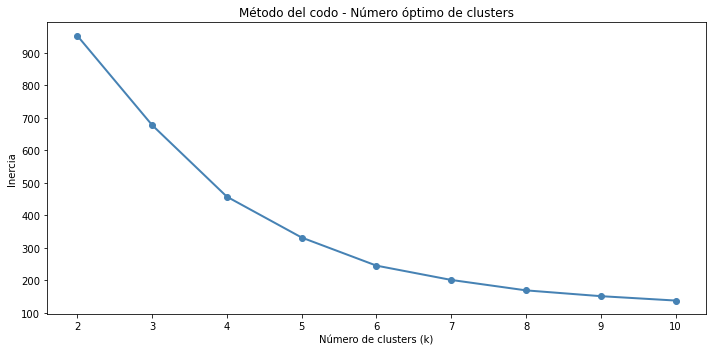

In [15]:
# Método del codo para encontrar número óptimo de clusters
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

# Variables opción 2: ubicación + profundidad
features_2 = col[['latitude', 'longitude', 'depth']].copy()

# Escalar los datos
scaler = StandardScaler()
X2 = scaler.fit_transform(features_2)

# Calcular inercia para diferentes números de clusters
inercias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X2)
    inercias.append(kmeans.inertia_)

# Graficar
plt.figure(figsize=(10, 5))
plt.plot(k_range, inercias, marker='o', color='steelblue', linewidth=2)
plt.title('Método del codo - Número óptimo de clusters')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.xticks(k_range)
plt.tight_layout()
plt.savefig('metodo_codo.png', dpi=150)
plt.show()

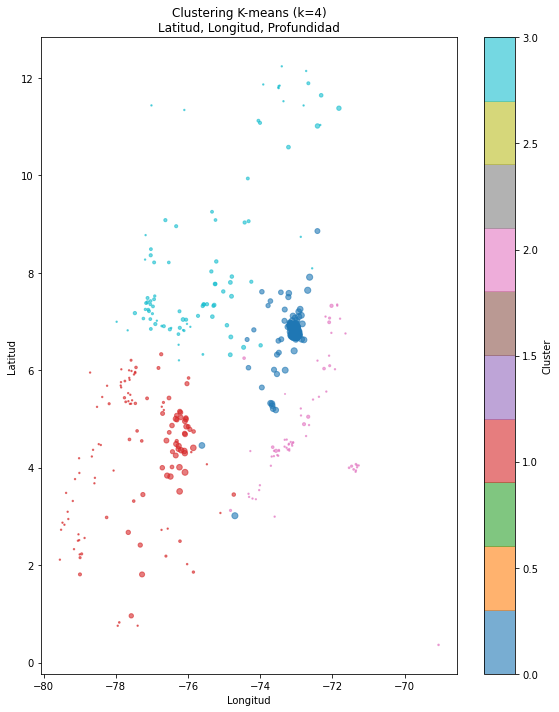

           latitude  longitude   depth   mag
cluster_2                                   
0              6.79     -73.10  152.80  4.36
1              4.24     -77.34   50.07  4.57
2              4.78     -72.79   14.95  4.55
3              8.32     -75.48   39.40  4.55


In [16]:
# K-means con k=4 - ubicación + profundidad
kmeans2 = KMeans(n_clusters=4, random_state=42, n_init=10)
col['cluster_2'] = kmeans2.fit_predict(X2)

# Visualizar
fig, ax = plt.subplots(figsize=(8, 10))
scatter = ax.scatter(
    col['longitude'],
    col['latitude'],
    c=col['cluster_2'],
    cmap='tab10',
    s=col['depth']/5,
    alpha=0.6
)
plt.colorbar(scatter, label='Cluster')
ax.set_title('Clustering K-means (k=4)\nLatitud, Longitud, Profundidad')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
plt.tight_layout()
plt.savefig('clustering_k4.png', dpi=150)
plt.show()

# Características de cada cluster
print(col.groupby('cluster_2')[['latitude','longitude','depth','mag']].mean().round(2))

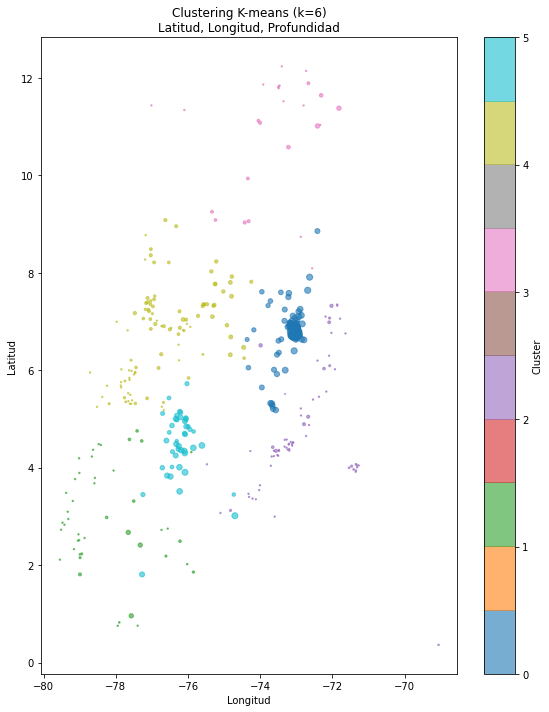

           latitude  longitude   depth   mag
cluster_6                                   
0              6.81     -73.09  152.68  4.36
1              2.93     -78.24   21.40  4.51
2              4.75     -72.85   15.16  4.54
3             10.85     -73.66   31.82  4.49
4              6.74     -76.67   33.51  4.61
5              4.45     -76.22  114.25  4.53


In [17]:
# K-means con k=6
kmeans6 = KMeans(n_clusters=6, random_state=42, n_init=10)
col['cluster_6'] = kmeans6.fit_predict(X2)

# Visualizar
fig, ax = plt.subplots(figsize=(8, 10))
scatter = ax.scatter(
    col['longitude'],
    col['latitude'],
    c=col['cluster_6'],
    cmap='tab10',
    s=col['depth']/5,
    alpha=0.6
)
plt.colorbar(scatter, label='Cluster')
ax.set_title('Clustering K-means (k=6)\nLatitud, Longitud, Profundidad')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
plt.tight_layout()
plt.savefig('clustering_k6.png', dpi=150)
plt.show()

print(col.groupby('cluster_6')[['latitude','longitude','depth','mag']].mean().round(2))

In [18]:
# Renombrar clusters con nombres geofísicos
nombres = {
    col.groupby('cluster_6')['latitude'].mean().idxmax(): 'Norte',
    col.groupby('cluster_6')['longitude'].mean().idxmin(): 'Pacífico',
    col.groupby('cluster_6')['latitude'].mean().idxmin(): 'Suroccidente',
    col.groupby('cluster_6')['depth'].mean().idxmax(): 'Santander',
}

print("Características por zona sismogénica:")
resumen = col.groupby('cluster_6').agg(
    cantidad=('mag','count'),
    prof_media=('depth','mean'),
    mag_media=('mag','mean'),
    lat_media=('latitude','mean'),
    lon_media=('longitude','mean')
).round(2)
print(resumen)

Características por zona sismogénica:
           cantidad  prof_media  mag_media  lat_media  lon_media
cluster_6                                                       
0               338      152.68       4.36       6.81     -73.09
1                45       21.40       4.51       2.93     -78.24
2                70       15.16       4.54       4.75     -72.85
3                26       31.82       4.49      10.85     -73.66
4               101       33.51       4.61       6.74     -76.67
5                43      114.25       4.53       4.45     -76.22


Clusters encontrados: 4
Puntos marcados como ruido: 78


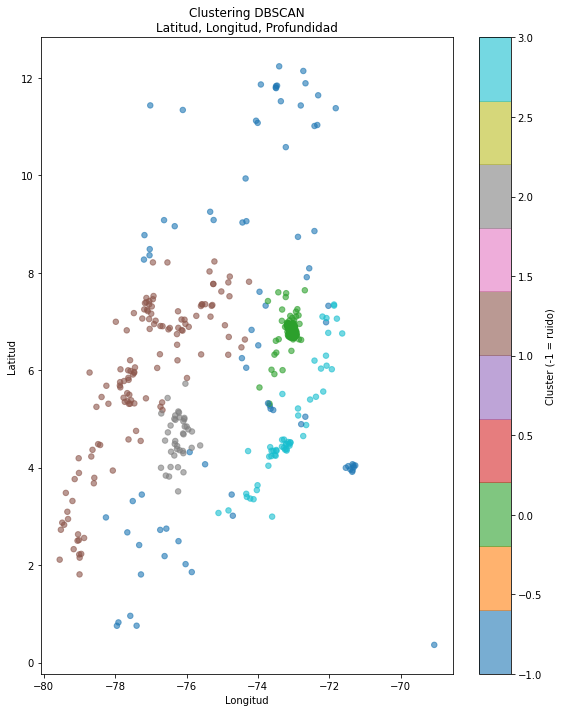

In [19]:
from sklearn.cluster import DBSCAN

# DBSCAN con ubicación + profundidad
dbscan = DBSCAN(eps=0.5, min_samples=10)
col['cluster_db'] = dbscan.fit_predict(X2)

# Cuántos clusters encontró
n_clusters = len(set(col['cluster_db'])) - (1 if -1 in col['cluster_db'].values else 0)
n_ruido = len(col[col['cluster_db'] == -1])

print(f"Clusters encontrados: {n_clusters}")
print(f"Puntos marcados como ruido: {n_ruido}")

# Visualizar
fig, ax = plt.subplots(figsize=(8, 10))
scatter = ax.scatter(
    col['longitude'],
    col['latitude'],
    c=col['cluster_db'],
    cmap='tab10',
    s=30,
    alpha=0.6
)
plt.colorbar(scatter, label='Cluster (-1 = ruido)')
ax.set_title('Clustering DBSCAN\nLatitud, Longitud, Profundidad')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
plt.tight_layout()
plt.savefig('clustering_dbscan.png', dpi=150)
plt.show()

In [20]:
print("=" * 55)
print("COMPARACIÓN DE ALGORITMOS DE CLUSTERING")
print("=" * 55)
print(f"\nK-means (k=6):")
print(f"- 6 zonas identificadas")
print(f"- 0 puntos descartados")
print(f"- Separa norte y suroccidente como zonas independientes")
print(f"\nDBSCAN:")
print(f"- {n_clusters} zonas identificadas")
print(f"- {n_ruido} puntos marcados como ruido ({n_ruido/len(col)*100:.1f}%)")
print(f"- Agrupa norte y sur en una sola zona")
print(f"\nAmbos coinciden en zonas principales:")
print(f"- Nido sísmico de Bucaramanga")
print(f"- Costa Pacífica")
print(f"- Piedemonte llanero")
print(f"- Zona norte-caribe")

COMPARACIÓN DE ALGORITMOS DE CLUSTERING

K-means (k=6):
- 6 zonas identificadas
- 0 puntos descartados
- Separa norte y suroccidente como zonas independientes

DBSCAN:
- 4 zonas identificadas
- 78 puntos marcados como ruido (12.5%)
- Agrupa norte y sur en una sola zona

Ambos coinciden en zonas principales:
- Nido sísmico de Bucaramanga
- Costa Pacífica
- Piedemonte llanero
- Zona norte-caribe


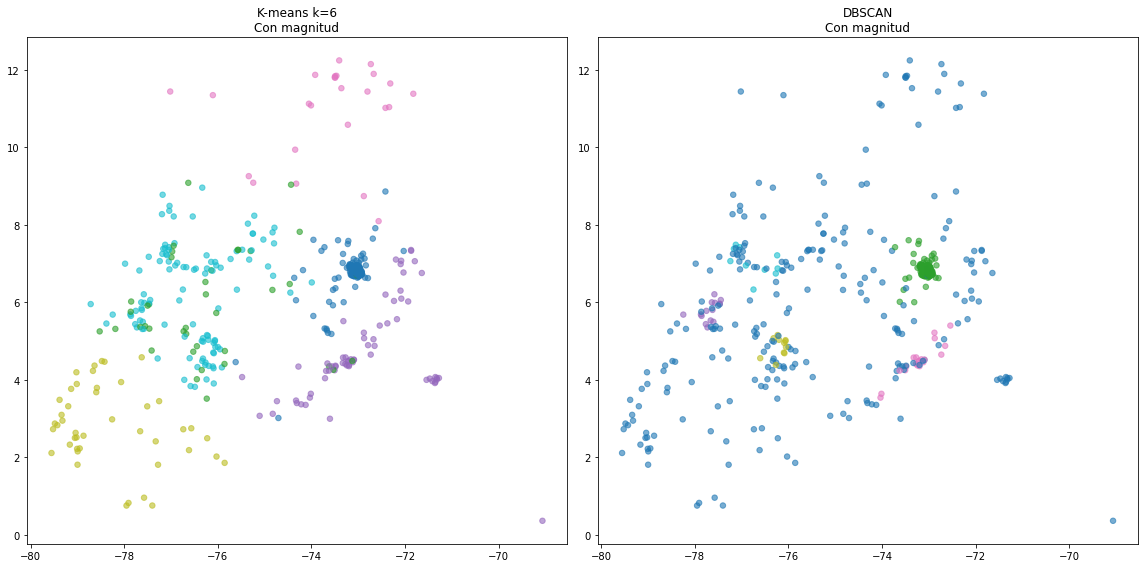

DBSCAN con magnitud:
- Clusters: 5
- Ruido: 251 (40.3%)


In [21]:
# Variables opción 3: ubicación + profundidad + magnitud
features_3 = col[['latitude', 'longitude', 'depth', 'mag']].copy()
X3 = scaler.fit_transform(features_3)

# K-means k=6
kmeans6_v3 = KMeans(n_clusters=6, random_state=42, n_init=10)
col['cluster_6_v3'] = kmeans6_v3.fit_predict(X3)

# DBSCAN
dbscan_v3 = DBSCAN(eps=0.5, min_samples=10)
col['cluster_db_v3'] = dbscan_v3.fit_predict(X3)

n_clusters_v3 = len(set(col['cluster_db_v3'])) - (1 if -1 in col['cluster_db_v3'].values else 0)
n_ruido_v3 = len(col[col['cluster_db_v3'] == -1])

# Visualizar lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].scatter(col['longitude'], col['latitude'],
    c=col['cluster_6_v3'], cmap='tab10', s=30, alpha=0.6)
axes[0].set_title('K-means k=6\nCon magnitud')

axes[1].scatter(col['longitude'], col['latitude'],
    c=col['cluster_db_v3'], cmap='tab10', s=30, alpha=0.6)
axes[1].set_title('DBSCAN\nCon magnitud')

plt.tight_layout()
plt.savefig('clustering_con_magnitud.png', dpi=150)
plt.show()

print(f"DBSCAN con magnitud:")
print(f"- Clusters: {n_clusters_v3}")
print(f"- Ruido: {n_ruido_v3} ({n_ruido_v3/len(col)*100:.1f}%)")

In [22]:
print("=" * 55)
print("CONCLUSIÓN: SELECCIÓN DE VARIABLES")
print("=" * 55)
print("\nVariables óptimas: latitud, longitud, profundidad")
print("Razón: la magnitud tiene baja varianza en el catálogo")
print(f"(std = {col['mag'].std():.2f} Mw) y genera traslape")
print("en K-means y pérdida de densidad en DBSCAN")
print("\nModelo seleccionado: K-means k=6")
print("Razón: identifica 6 zonas con sentido geofísico")
print("sin descartar puntos del catálogo")

CONCLUSIÓN: SELECCIÓN DE VARIABLES

Variables óptimas: latitud, longitud, profundidad
Razón: la magnitud tiene baja varianza en el catálogo
(std = 0.31 Mw) y genera traslape
en K-means y pérdida de densidad en DBSCAN

Modelo seleccionado: K-means k=6
Razón: identifica 6 zonas con sentido geofísico
sin descartar puntos del catálogo
